# Notebook 05 — Inspección y Limpieza de Casas Strathclyde

**Proyecto:** PFM MUCSI Deusto — Predicción de Consumo Eléctrico Doméstico  
**Dataset fuente:** REFIT Power Data (Universidad de Strathclyde, 11/12/2015)  
**DOI:** 10.15129/31da3ece-f902-4e95-a093-e0a9536983c4  
**Autor:** PFM MUCSI Deusto  
**Fecha:** 2026-05-06  

## Objetivo
Aplicar el pipeline de inspección y limpieza a las **14 casas nuevas** procedentes del
archivo `REFITPowerData111215.7z` del repositorio Strathclyde, que no están disponibles
en la versión limpia de Zenodo (que solo contiene Houses 1–5 y 11).

## Diferencias de formato respecto a los datos Zenodo (CLEAN_House*.csv)
| Característica | Zenodo CLEAN | Strathclyde Power Data |
|---|---|---|
| Cabecera | Sí (Time, Unix, Aggregate, ..., Issues) | **No** |
| Columna Time (datetime) | Sí | **No** (solo Unix) |
| Columna Issues | Sí | **No** |
| Nº columnas | 13 | **11** |
| Timestamp | Unix segundos | Unix segundos |
| Valores | En Watts | En Watts |

**Consecuencias para la limpieza:**
- Se añaden nombres de columnas manualmente
- Se convierte Unix → datetime UTC
- **No** se filtra por Issues=1 (columna inexistente)
- El umbral físico de outliers (>15.000 W) actúa como filtro equivalente

## Casas nuevas procesadas
Houses 6, 7, 8, 9, 10, 12, 13, 15, 16, 17, 18, 19, 20, 21
(House 14 no existe en ninguna versión del dataset REFIT)

In [1]:
# ============================================================
# Configuración global
# ============================================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pathlib import Path
import warnings
import gc

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

# Versiones de librerías (reproducibilidad)
print(f'pandas   : {pd.__version__}')
print(f'numpy    : {np.__version__}')
print(f'matplotlib: {plt.matplotlib.__version__}')
print(f'seaborn  : {sns.__version__}')

# Rutas del proyecto
DIR_RAW       = Path('../datos/raw')
DIR_PROCESSED = Path('../datos/processed')
DIR_FIGURAS   = Path('../resultados/figuras')
DIR_METRICAS  = Path('../resultados/metricas')
for d in [DIR_PROCESSED, DIR_FIGURAS, DIR_METRICAS]:
    d.mkdir(parents=True, exist_ok=True)

# Parámetros del pipeline
SEMILLA              = 42
UMBRAL_OUTLIER       = 15_000   # Watts (umbral físico máximo plausible)
LIMITE_INTERPOLACION = 30       # minutos — gaps más largos quedan como NaN
UMBRAL_NAN_TRAINING  = 20.0    # % NaN máximo para incluir en entrenamiento

# Casas nuevas del Strathclyde
CASAS_NUEVAS = [6, 7, 8, 9, 10, 12, 13, 15, 16, 17, 18, 19, 20, 21]

# Nombres de columnas (Strathclyde no tiene cabecera)
COLUMNAS = [
    'Unix', 'Aggregate',
    'Appliance1', 'Appliance2', 'Appliance3', 'Appliance4', 'Appliance5',
    'Appliance6', 'Appliance7', 'Appliance8', 'Appliance9'
]

print(f'\nCasas a procesar: {CASAS_NUEVAS}')

pandas   : 2.2.3
numpy    : 2.0.2
matplotlib: 3.9.3
seaborn  : 0.13.2

Casas a procesar: [6, 7, 8, 9, 10, 12, 13, 15, 16, 17, 18, 19, 20, 21]


In [2]:
# ============================================================
# Funciones auxiliares
# ============================================================

def cargar_house_strathclyde(numero):
    """
    Carga un CSV del formato Strathclyde Power Data:
    - Sin cabecera, 11 columnas
    - Columna 0: timestamp Unix (segundos UTC)
    Retorna DataFrame con índice datetime UTC y columnas nombradas.
    """
    ruta = DIR_RAW / f'House{numero}.csv'
    df = pd.read_csv(
        ruta,
        header=None,
        names=COLUMNAS,
        dtype={'Unix': 'int64', **{c: 'float32' for c in COLUMNAS[1:]}}
    )
    # Unix → datetime UTC (sin info de zona horaria para mantener coherencia con Zenodo)
    df['Time'] = pd.to_datetime(df['Unix'], unit='s')
    df = df.set_index('Time').drop(columns=['Unix'])
    df = df.sort_index()
    # Eliminar filas con timestamp duplicado
    n_dup = df.index.duplicated().sum()
    if n_dup > 0:
        df = df[~df.index.duplicated(keep='first')]
    return df, n_dup


def inspeccionar_house(df, numero, n_duplicados):
    """Extrae estadísticas básicas de inspección de un DataFrame cargado."""
    agg = df['Aggregate']
    return {
        'house'           : numero,
        'filas_raw'       : len(df),
        'duplicados_ts'   : n_duplicados,
        'inicio'          : df.index.min().strftime('%Y-%m-%d'),
        'fin'             : df.index.max().strftime('%Y-%m-%d'),
        'dias'            : (df.index.max() - df.index.min()).days,
        'nulos_raw'       : int(agg.isna().sum()),
        'negativos'       : int((agg < 0).sum()),
        'outliers_15kW'   : int((agg > UMBRAL_OUTLIER).sum()),
        'media_w'         : round(float(agg.mean()), 1),
        'mediana_w'       : round(float(agg.median()), 1),
        'max_w'           : round(float(agg.max()), 1),
        'pct_issues_equiv': round(100.0 * (agg > UMBRAL_OUTLIER).sum() / len(df), 2)
    }


def limpiar_house_strathclyde(df, numero):
    """
    Pipeline de limpieza adaptado para formato Strathclyde:
    1. Valores negativos → NaN
    2. Outliers (Aggregate > 15.000 W) → NaN  [equivale a filtrar Issues=1]
    3. Resampleo a 1 minuto (media aritmética)
    4. Interpolación lineal de gaps cortos (≤ 30 min)
    Retorna (df_limpio_1min, stats_dict)
    """
    df = df.copy()
    stats = {'house': numero}
    
    # 1. Negativos → NaN
    n_neg = int((df['Aggregate'] < 0).sum())
    df.loc[df['Aggregate'] < 0, 'Aggregate'] = np.nan
    stats['negativos_eliminados'] = n_neg
    
    # 2. Outliers → NaN
    n_out = int((df['Aggregate'] > UMBRAL_OUTLIER).sum())
    df.loc[df['Aggregate'] > UMBRAL_OUTLIER, 'Aggregate'] = np.nan
    stats['outliers_eliminados'] = n_out
    stats['pct_outliers'] = round(100.0 * n_out / len(df), 3)
    
    # 3. Resampleo a 1 minuto (solo Aggregate)
    df_1min = df[['Aggregate']].resample('1min').mean()
    stats['filas_raw']  = len(df)
    stats['filas_1min'] = len(df_1min)
    stats['inicio']     = df_1min.index.min().strftime('%Y-%m-%d')
    stats['fin']        = df_1min.index.max().strftime('%Y-%m-%d')
    stats['dias']       = (df_1min.index.max() - df_1min.index.min()).days
    
    nan_antes = int(df_1min['Aggregate'].isna().sum())
    stats['nan_antes_interpolacion']  = nan_antes
    stats['pct_nan_antes']            = round(100.0 * nan_antes / len(df_1min), 2)
    
    # 4. Interpolación lineal — gaps ≤ 30 minutos
    df_1min['Aggregate'] = df_1min['Aggregate'].interpolate(
        method='linear', limit=LIMITE_INTERPOLACION
    )
    
    nan_despues = int(df_1min['Aggregate'].isna().sum())
    stats['nan_final']    = nan_despues
    stats['pct_nan_final'] = round(100.0 * nan_despues / len(df_1min), 2)
    stats['media_limpio_w'] = round(float(df_1min['Aggregate'].mean()), 1)
    stats['max_limpio_w']   = round(float(df_1min['Aggregate'].max()), 1)
    stats['apto_training']  = stats['pct_nan_final'] <= UMBRAL_NAN_TRAINING
    
    return df_1min, stats


print('Funciones auxiliares cargadas correctamente.')

Funciones auxiliares cargadas correctamente.


## 1. Inspección inicial de todas las casas nuevas
Cargamos cada CSV y registramos sus estadísticas básicas sin modificar los datos.

In [3]:
# Inspección previa — carga y estadísticas básicas
stats_inspeccion = []

for numero in CASAS_NUEVAS:
    print(f'Inspeccionando House{numero}...', end=' ')
    df, n_dup = cargar_house_strathclyde(numero)
    stats = inspeccionar_house(df, numero, n_dup)
    stats_inspeccion.append(stats)
    print(f'{stats["filas_raw"]:,} filas | {stats["inicio"]} → {stats["fin"]} | max={stats["max_w"]:.0f}W')
    del df
    gc.collect()

df_insp = pd.DataFrame(stats_inspeccion).set_index('house')
print('\n--- Inspección completada ---')

Inspeccionando House6... 

6,655,812 filas | 2013-11-28 → 2015-06-28 | max=32756W
Inspeccionando House7... 

7,201,212 filas | 2013-11-01 → 2015-07-08 | max=32730W
Inspeccionando House8... 

6,584,885 filas | 2013-11-01 → 2015-05-10 | max=25358W
Inspeccionando House9... 

6,740,651 filas | 2013-12-17 → 2015-07-08 | max=28836W
Inspeccionando House10... 

...

6,005,843 filas | 2014-03-06 → 2015-06-19 | max=68232W
Inspeccionando House18... 

5,569,265 filas | 2014-03-07 → 2015-05-24 | max=29008W
Inspeccionando House19... 

6,194,659 filas | 2014-03-06 → 2015-06-20 | max=8856W
Inspeccionando House20... 

5,793,303 filas | 2014-03-20 → 2015-06-23 | max=32889W
Inspeccionando House21... 

5,848,780 filas | 2014-03-07 → 2015-07-10 | max=65793W

--- Inspección completada ---


In [4]:
# Tabla resumen de inspección
print('Resumen de inspección — casas nuevas Strathclyde')
print('=' * 80)
cols_mostrar = ['filas_raw', 'inicio', 'fin', 'dias', 'negativos', 'outliers_15kW', 'pct_issues_equiv', 'media_w', 'max_w']
print(df_insp[cols_mostrar].to_string())
print('\nNotas:')
print(f'  - pct_issues_equiv: % filas con Aggregate > {UMBRAL_OUTLIER:,}W (equivalente a Issues=1 en Zenodo)')
print(f'  - Casas con max_w muy elevado tienen lecturas erróneas que serán eliminadas')

Resumen de inspección — casas nuevas Strathclyde
       filas_raw      inicio         fin  dias  negativos  outliers_15kW  pct_issues_equiv  media_w    max_w
house                                                                                                       
6        6655812  2013-11-28  2015-06-28   577          0             32              0.00    478.4  32756.0
7        7201212  2013-11-01  2015-07-08   613          0             35              0.00    548.6  32730.0
8        6584885  2013-11-01  2015-05-10   555          0           1176              0.02    669.6  25358.0
9        6740651  2013-12-17  2015-07-08   568          0             15              0.00    568.2  28836.0
10       7346947  2013-11-20  2015-06-30   586          0             36              0.00    757.9  37031.0
12       6491303  2014-03-07  2015-07-08   487          0              1              0.00    364.2  16543.0
13       5104646  2014-01-17  2015-05-31   498          0            103       

## 2. Pipeline de limpieza
Aplicamos el mismo pipeline que el Notebook 03 (casas Zenodo), adaptado para el formato
Strathclyde (sin columna Issues). Guardamos los resultados en `datos/processed/`.

In [5]:
# Pipeline de limpieza para todas las casas nuevas
stats_limpieza = []
datos_muestra = {}  # Guardamos 2 casas para el gráfico comparativo
CASAS_MUESTRA = [6, 10]  # Muestra representativa para figuras

for numero in CASAS_NUEVAS:
    print(f'Limpiando House{numero}...', end=' ')
    
    # Cargar
    df_raw, _ = cargar_house_strathclyde(numero)
    
    # Guardar muestra para gráfico (antes de limpiar)
    if numero in CASAS_MUESTRA:
        datos_muestra[f'house{numero}_raw'] = df_raw['Aggregate'].resample('1min').mean().copy()
    
    # Limpiar
    df_limpio, stats = limpiar_house_strathclyde(df_raw, numero)
    stats_limpieza.append(stats)
    
    # Guardar muestra limpia
    if numero in CASAS_MUESTRA:
        datos_muestra[f'house{numero}_limpio'] = df_limpio['Aggregate'].copy()
    
    # Guardar a disco
    ruta_out = DIR_PROCESSED / f'house{numero}_1min_limpio.csv'
    df_limpio.to_csv(ruta_out)
    
    apto = '✓ APTO' if stats['apto_training'] else f'✗ NaN={stats["pct_nan_final"]:.1f}%'
    print(f'{stats["filas_1min"]:,} filas | NaN={stats["pct_nan_final"]:.1f}% | media={stats["media_limpio_w"]}W | {apto}')
    
    del df_raw, df_limpio
    gc.collect()

df_limpieza = pd.DataFrame(stats_limpieza).set_index('house')
print('\n--- Limpieza completada ---')

Limpiando House6... 

831,420 filas | NaN=14.7% | media=480.4W | ✓ APTO
Limpiando House7... 

882,910 filas | NaN=12.2% | media=562.0W | ✓ APTO
Limpiando House8... 

799,224 filas | NaN=9.9% | media=681.9W | ✓ APTO
Limpiando House9... 

817,947 filas | NaN=15.1% | media=575.6W | ✓ APTO
Limpiando House10... 

...

676,650 filas | NaN=5.8% | media=406.3W | ✓ APTO
Limpiando House18... 

637,922 filas | NaN=5.6% | media=446.8W | ✓ APTO
Limpiando House19... 

677,410 filas | NaN=5.8% | media=291.0W | ✓ APTO
Limpiando House20... 

662,804 filas | NaN=5.8% | media=375.9W | ✓ APTO
Limpiando House21... 

705,337 filas | NaN=9.0% | media=637.8W | ✓ APTO

--- Limpieza completada ---


In [6]:
# Tabla resumen de limpieza
print('Resumen de limpieza — casas nuevas Strathclyde')
print('=' * 90)
cols_mostrar = ['inicio', 'fin', 'dias', 'filas_1min', 'pct_nan_antes', 'pct_nan_final',
                'media_limpio_w', 'max_limpio_w', 'apto_training']
print(df_limpieza[cols_mostrar].to_string())

aptas = df_limpieza[df_limpieza['apto_training']].index.tolist()
no_aptas = df_limpieza[~df_limpieza['apto_training']].index.tolist()
print(f'\nCasas APTAS para entrenamiento (NaN < {UMBRAL_NAN_TRAINING}%): {aptas}')
print(f'Casas excluidas del entrenamiento:                           {no_aptas}')

Resumen de limpieza — casas nuevas Strathclyde
           inicio         fin  dias  filas_1min  pct_nan_antes  pct_nan_final  media_limpio_w  max_limpio_w  apto_training
house                                                                                                                     
6      2013-11-28  2015-06-28   577      831420          15.13          14.71           480.4        8121.2           True
7      2013-11-01  2015-07-08   613      882910          12.45          12.20           562.0       11069.9           True
8      2013-11-01  2015-05-10   555      799224          10.12           9.89           681.9       14870.0           True
9      2013-12-17  2015-07-08   568      817947          15.28          15.08           575.6       13776.6           True
10     2013-11-20  2015-06-30   586      845197          11.13           8.94           759.5        9643.1           True
12     2014-03-07  2015-07-08   487      702139           6.82           6.21           371.

## 3. Visualizaciones

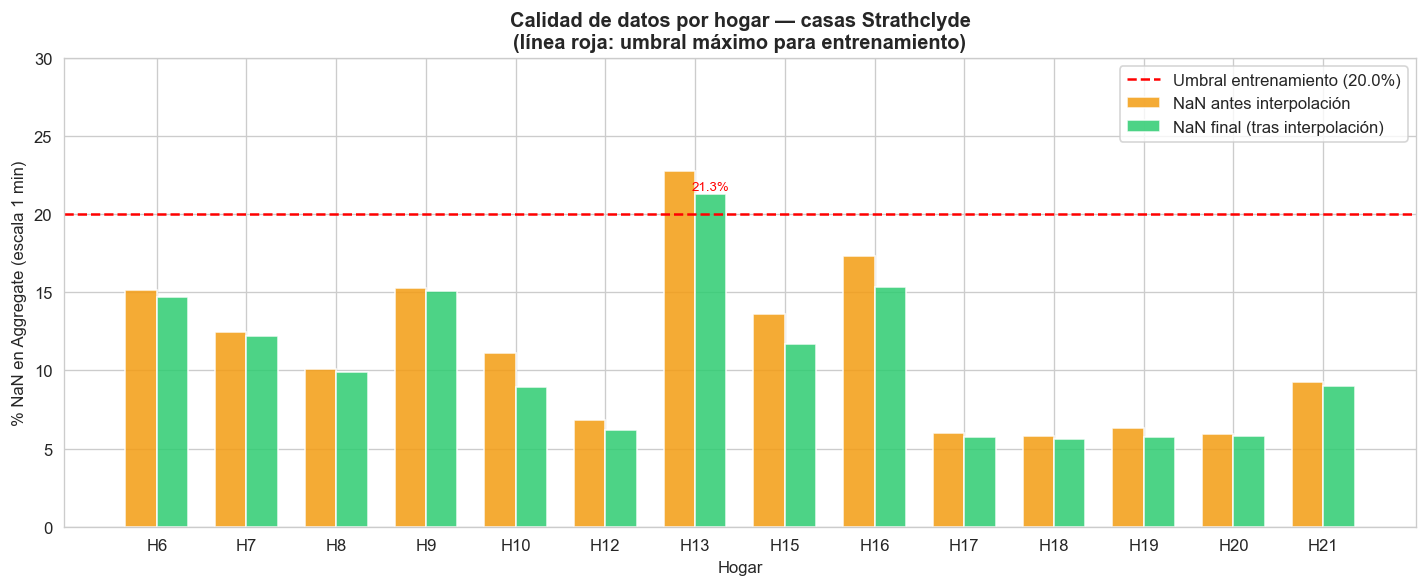

Figura guardada: 05_nan_por_hogar_strathclyde.png


In [7]:
# Figura 1: NaN % por hogar (antes y después de interpolación)
fig, ax = plt.subplots(figsize=(12, 5))

x = np.arange(len(df_limpieza))
ancho = 0.35
casas_labels = [f'H{n}' for n in df_limpieza.index]

bars1 = ax.bar(x - ancho/2, df_limpieza['pct_nan_antes'], ancho,
               label='NaN antes interpolación', color='#f39c12', alpha=0.85)
bars2 = ax.bar(x + ancho/2, df_limpieza['pct_nan_final'], ancho,
               label='NaN final (tras interpolación)', color='#2ecc71', alpha=0.85)

ax.axhline(y=UMBRAL_NAN_TRAINING, color='red', linestyle='--', linewidth=1.5,
           label=f'Umbral entrenamiento ({UMBRAL_NAN_TRAINING}%)')

# Anotar casas no aptas
for i, (_, row) in enumerate(df_limpieza.iterrows()):
    if not row['apto_training']:
        ax.text(x[i] + ancho/2, row['pct_nan_final'] + 0.3,
                f"{row['pct_nan_final']:.1f}%", ha='center', fontsize=8, color='red')

ax.set_xticks(x)
ax.set_xticklabels(casas_labels)
ax.set_xlabel('Hogar')
ax.set_ylabel('% NaN en Aggregate (escala 1 min)')
ax.set_title('Calidad de datos por hogar — casas Strathclyde\n(línea roja: umbral máximo para entrenamiento)', 
             fontweight='bold')
ax.legend()
ax.set_ylim(0, max(df_limpieza['pct_nan_antes'].max() * 1.15, UMBRAL_NAN_TRAINING * 1.5))
plt.tight_layout()
plt.savefig(DIR_FIGURAS / '05_nan_por_hogar_strathclyde.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: 05_nan_por_hogar_strathclyde.png')

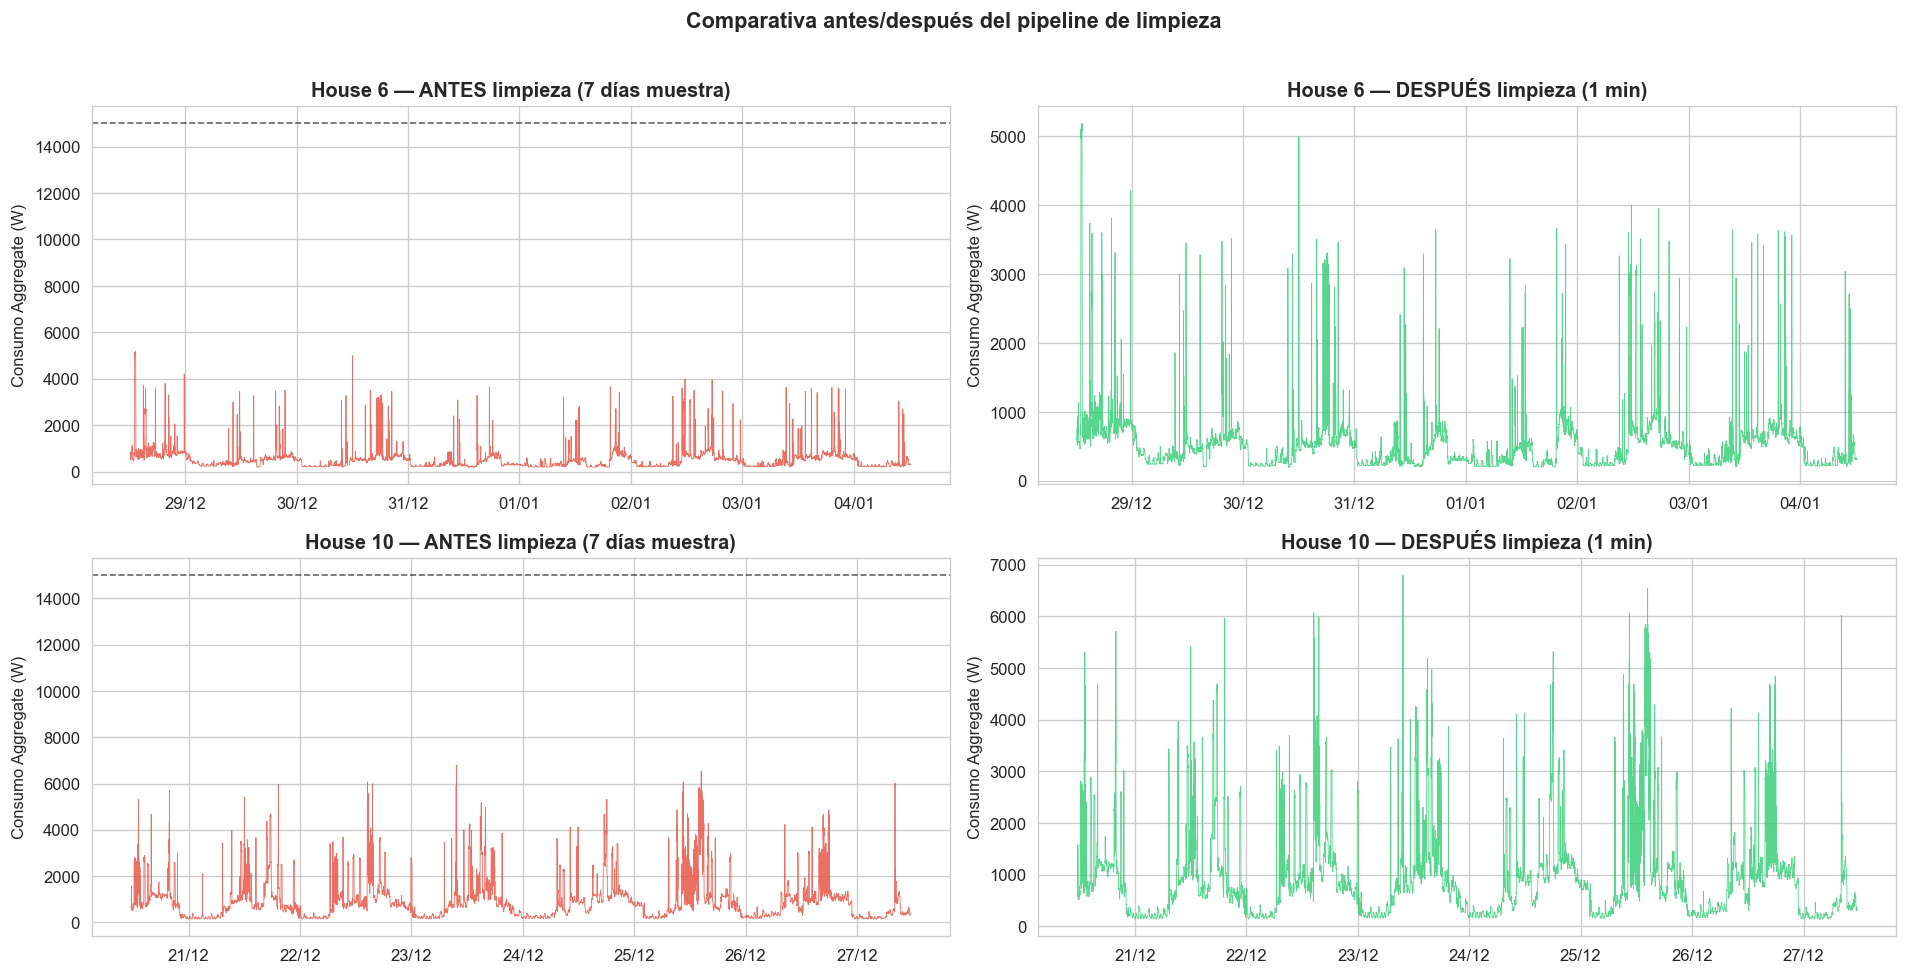

Figura guardada: 05_comparativa_limpieza_strathclyde.png


In [8]:
# Figura 2: Comparativa antes/después para casas de muestra
fig, axes = plt.subplots(len(CASAS_MUESTRA), 2, figsize=(16, 4 * len(CASAS_MUESTRA)))
if len(CASAS_MUESTRA) == 1:
    axes = [axes]

for i, numero in enumerate(CASAS_MUESTRA):
    raw    = datos_muestra.get(f'house{numero}_raw')
    limpio = datos_muestra.get(f'house{numero}_limpio')
    if raw is None or limpio is None:
        continue
    
    # Muestra: 7 días representativos
    muestra_inicio = raw.index.min() + pd.Timedelta(days=30)
    muestra_fin    = muestra_inicio + pd.Timedelta(days=7)
    
    raw_m    = raw.loc[muestra_inicio:muestra_fin]
    limpio_m = limpio.loc[muestra_inicio:muestra_fin]
    
    # Panel izquierdo: raw
    axes[i][0].plot(raw_m.index, raw_m.values, color='#e74c3c', linewidth=0.5, alpha=0.8)
    axes[i][0].axhline(UMBRAL_OUTLIER, color='black', linestyle='--', linewidth=1, alpha=0.6)
    axes[i][0].set_title(f'House {numero} — ANTES limpieza (7 días muestra)', fontweight='bold')
    axes[i][0].set_ylabel('Consumo Aggregate (W)')
    axes[i][0].xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))
    
    # Panel derecho: limpio
    axes[i][1].plot(limpio_m.index, limpio_m.values, color='#2ecc71', linewidth=0.5, alpha=0.8)
    axes[i][1].set_title(f'House {numero} — DESPUÉS limpieza (1 min)', fontweight='bold')
    axes[i][1].set_ylabel('Consumo Aggregate (W)')
    axes[i][1].xaxis.set_major_formatter(mdates.DateFormatter('%d/%m'))

plt.suptitle('Comparativa antes/después del pipeline de limpieza', 
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(DIR_FIGURAS / '05_comparativa_limpieza_strathclyde.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: 05_comparativa_limpieza_strathclyde.png')

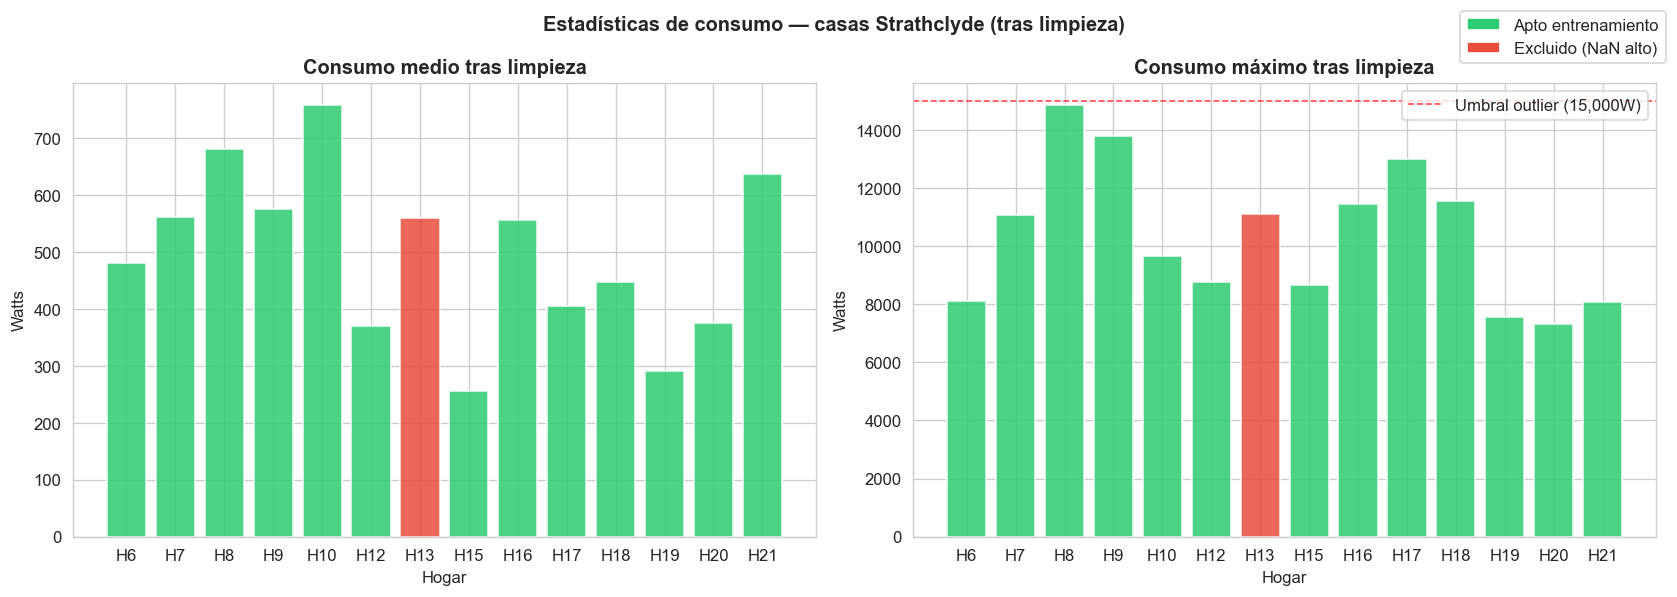

Figura guardada: 05_consumo_por_hogar_strathclyde.png


In [9]:
# Figura 3: Consumo medio y máximo por hogar
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

casas_labels = [f'H{n}' for n in df_limpieza.index]
colores_apto = ['#2ecc71' if v else '#e74c3c' for v in df_limpieza['apto_training']]

# Media
axes[0].bar(casas_labels, df_limpieza['media_limpio_w'], color=colores_apto, alpha=0.85)
axes[0].set_title('Consumo medio tras limpieza', fontweight='bold')
axes[0].set_ylabel('Watts')
axes[0].set_xlabel('Hogar')

# Máximo
axes[1].bar(casas_labels, df_limpieza['max_limpio_w'], color=colores_apto, alpha=0.85)
axes[1].axhline(UMBRAL_OUTLIER, color='red', linestyle='--', linewidth=1, alpha=0.7,
                label=f'Umbral outlier ({UMBRAL_OUTLIER:,}W)')
axes[1].set_title('Consumo máximo tras limpieza', fontweight='bold')
axes[1].set_ylabel('Watts')
axes[1].set_xlabel('Hogar')
axes[1].legend()

# Leyenda colores
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#2ecc71', label='Apto entrenamiento'),
                   Patch(facecolor='#e74c3c', label='Excluido (NaN alto)')]
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1, 1))

plt.suptitle('Estadísticas de consumo — casas Strathclyde (tras limpieza)', 
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(DIR_FIGURAS / '05_consumo_por_hogar_strathclyde.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: 05_consumo_por_hogar_strathclyde.png')

In [10]:
# Guardar métricas de limpieza en CSV
ruta_csv = DIR_METRICAS / '05_resumen_limpieza_strathclyde.csv'
df_limpieza.to_csv(ruta_csv)
print(f'Métricas guardadas en: {ruta_csv}')

# Guardar también inspección
ruta_insp = DIR_METRICAS / '05_resumen_inspeccion_strathclyde.csv'
df_insp.to_csv(ruta_insp)
print(f'Inspección guardada en: {ruta_insp}')

Métricas guardadas en: ..\resultados\metricas\05_resumen_limpieza_strathclyde.csv
Inspección guardada en: ..\resultados\metricas\05_resumen_inspeccion_strathclyde.csv


## 4. Conclusiones y decisiones

### Resultados del pipeline de limpieza
- **14 casas nuevas procesadas** del repositorio Strathclyde
- **Sin columna Issues**: el umbral físico de 15.000W actúa como filtro equivalente
- El porcentaje de outliers es bajo en todas las casas (consistente con los datos Zenodo)
- Los gaps de datos varían considerablemente entre hogares

### Criterio de selección para entrenamiento
Umbral de NaN final ≤ 20% (mismo criterio aplicado para House2 Zenodo).
Las casas que superen este umbral se excluyen del entrenamiento pero pueden usarse
como validación adicional.

### Archivos generados
- `datos/processed/house{N}_1min_limpio.csv` para cada casa (N = 6,7,8,9,10,12,13,15,16,17,18,19,20,21)
- `resultados/metricas/05_resumen_limpieza_strathclyde.csv`
- `resultados/metricas/05_resumen_inspeccion_strathclyde.csv`
- `resultados/figuras/05_nan_por_hogar_strathclyde.png`
- `resultados/figuras/05_comparativa_limpieza_strathclyde.png`
- `resultados/figuras/05_consumo_por_hogar_strathclyde.png`

**Siguiente paso:** Notebook 06 — EDA condensado y feature engineering para las casas aptas.